In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    Dataset,
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    metrics_grid,
    plot_grid,
    plot_ball_behavior,
    plot_all_trajectories,
    plot
)
import plotly.express as px
from src.classify import classify_trajectories
from scipy.fft import fft, fft2, fftshift
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import xarray as xr

In [3]:
model = "bruss"
df0 = pd.DataFrame()
frames = []
for ds_id in ["rough", "rough2"]:
    ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
    df = ds.df
    df0 = pd.concat([df0, df])
    f = ds.dataset["data"][:, -1, :, 0::2]
    frames.append(f)
frames = np.concatenate(frames)

In [4]:
def fft_features(img):
    f = fft2(img)
    fshift = fftshift(f)
    mag = np.abs(fshift)
    mag_log = np.log1p(mag)
    return mag_log


def classify_pca_fft(frames, n_components=10, n_clusters=3):
    """
    Classify images using PCA and FFT features
    """
    # Apply FFT to all frames
    fft_images = np.array([fft_features(img) for img in frames])

    # Flatten and apply PCA
    X_fft = fft_images.reshape(len(frames), -1)
    X_std = StandardScaler().fit_transform(X_fft)
    X_pca = PCA(n_components=n_components).fit_transform(X_std)

    # Apply KMeans clustering
    labels = KMeans(n_clusters=n_clusters).fit_predict(X_pca)

    return labels


def classify_pca(ds: Dataset, n_components=10, n_clusters=3):
    """
    Classify images using PCA features
    """
    # Load final frames
    dataset = xr.open_dataset(ds.ds_file)
    frames = dataset["data"][:, -1, :, 0::2].values

    return classify_pca_fft(frames, n_components, n_clusters)

NameError: name 'Dataset' is not defined

In [5]:
df0["pca_label"] = classify_pca_fft(frames)
df0["ratio_b_a"] = df0["B"] / df0["A"]
df0["ratio_d"] = df0["Dv"] / df0["Du"]

In [6]:
model = "bruss"
ds_id = "rough2"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [4]:
df1 = df
# df1["is_lab"] = 0
# df1.loc[[2, 108, 146, 192, 221, 278, 286, 324, 333, 392], "is_lab"] = 1

In [7]:
# df1["q"] = df1["glcm_energy"]
# df1 = df1[(df1.ratio_d < 8) & (df1.rel_std_u > 1e-1)] # (df1.q.between(500, 2000)) & 
# df1.loc[[1104, 102, 1690, 104], "category"] = "AA"
fig = px.scatter_3d(
    df0,
    x="A",
    y="ratio_b_a",
    z="mean_deviation", 
    color="pca_label", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

231


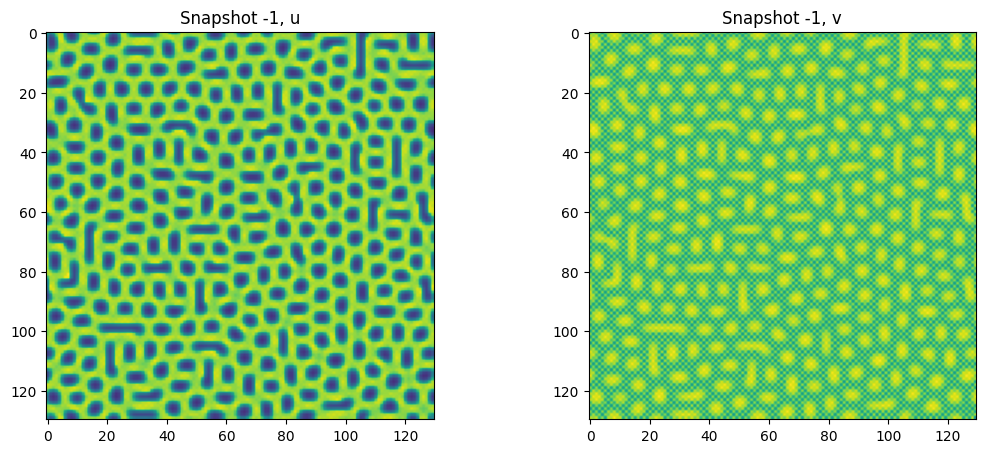

15


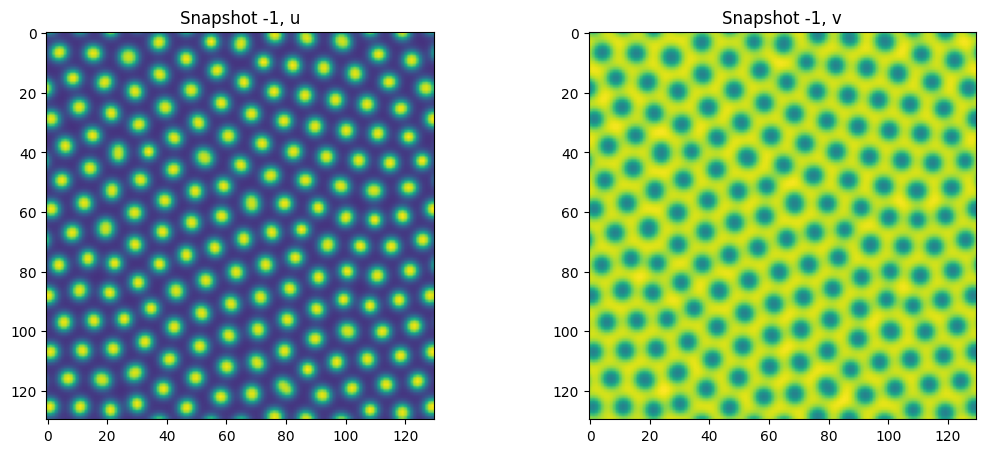

249


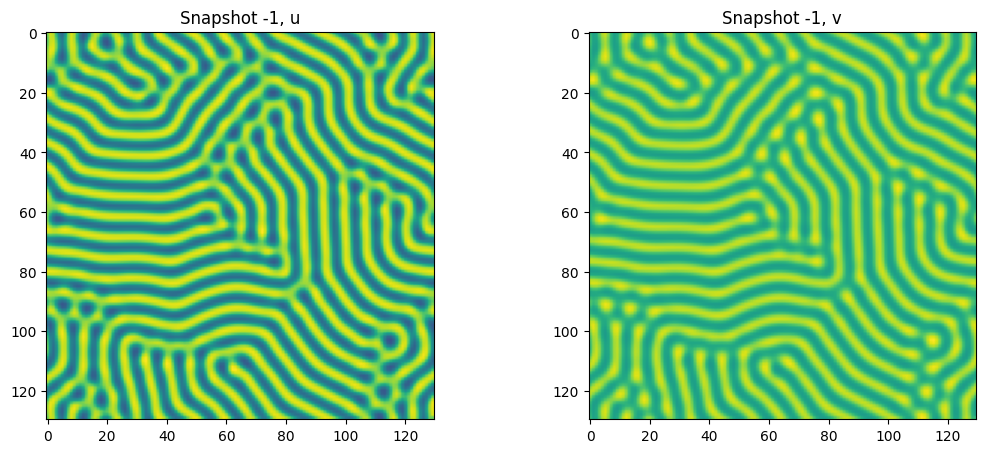

287


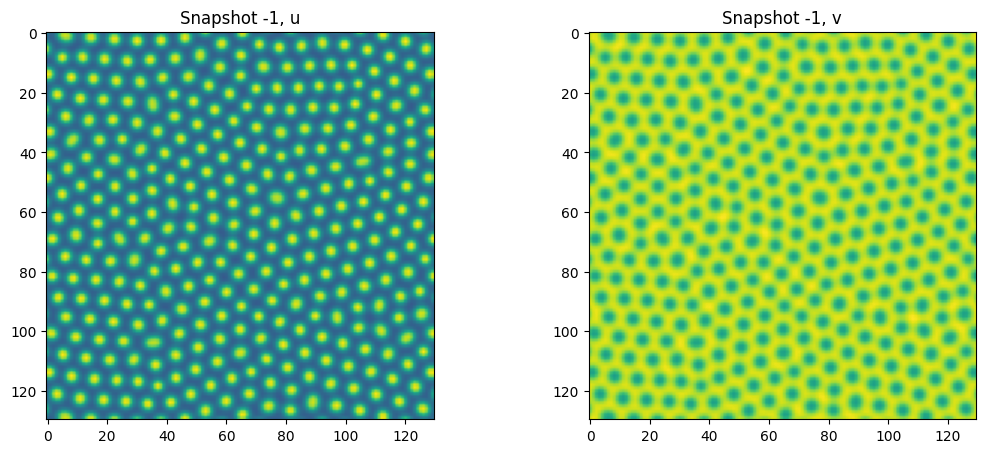

154


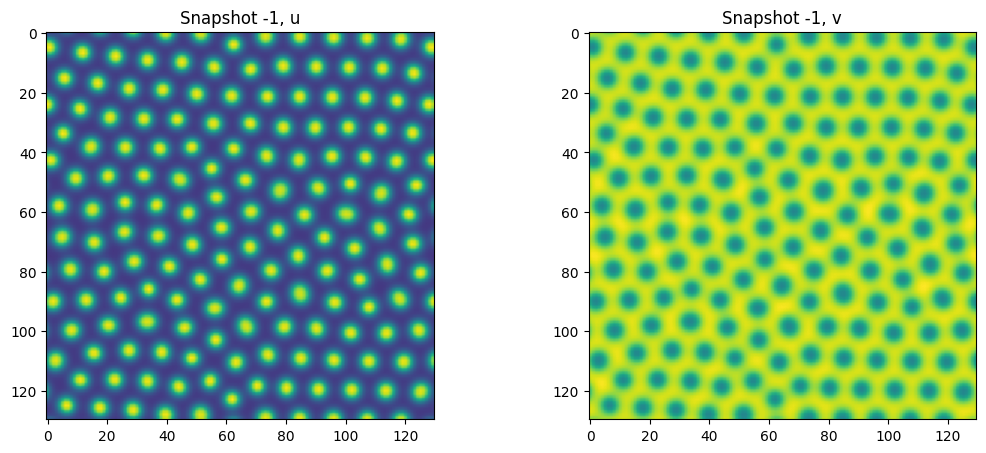

In [7]:
df_filt = df[df.pca_label == 2]

for i, row in df_filt.sample(5).iterrows():
    print(i)
    d = ds.get_data(i)
    plot(d, 0, np.max(d))
    plt.show()

In [5]:
i = 23
d = ds.get_data(i)
make_animation(d, str(i), ".")

MovieWriter ffmpeg unavailable; using Pillow instead.


In [10]:
df1 = df[df.idx == 249]
df1 = df1[["A", "B", "Du", "Dv"]]
df1.to_csv("one.csv")

In [41]:
model = "bruss"
ds_id = "rough2"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df_rem = ds.df

In [22]:
model = "bruss"
ds_id = "rough2"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR", "_dataset_with_nan.nc")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [50]:
df_rem_sub = df_rem[df_rem.Du == 1.]
df_rem_sub.value_counts("pca_label")

pca_label
0    117
2     69
1     59
Name: count, dtype: int64

In [23]:
ds2 = xr.open_dataset('/cluster/scratch/vogtva/data/bruss/rough2/_dataset_with_nan.nc')

In [12]:
arr = ds2["data"]
axes = (1,2,3)

In [35]:
nan_indices = np.where(np.isnan(arr).any(axis=axes))[0]

In [37]:
df["is_nan"] = 0
df.loc[nan_indices, "is_nan"] = 1

In [38]:
df.value_counts("is_nan")

is_nan
0    385
1    105
Name: count, dtype: int64

In [46]:
fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_b_a",
    z="Du", 
    color="is_nan", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()